### Evidencia clase 27-08
#### Paulina Benito

Aclaración: trabajé a partir del código que mandaron por zoom para ir siguiendo mejor la clase.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest
fs = 1000 
N = 1000 
vmax = np.sqrt(2) 
dc = 0 
ff = 3 
ph = 0 
SNR = 10 
Psen = 1 
ur = 0 

k=4
delta_f=1

def gen_sin (vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):

    #genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    #genero un vector con los valores de 'dc + vmax.Sen(2pi.ff.tt + ph)' para cada valor de tt
    xx = dc + vmax * np.sin (2 * np.pi * ff * tt + ph)
    
    return tt, xx 


# Generador de ruido
def gen_noise (SNR = SNR, Psen = Psen, ur = ur, nn = N):

    #despejo la potencia del ruido en función de SNR y Psen    
    Pr = Psen / (10**(SNR/10))
     
    #calculo la desviación estandar del ruido en base a Pr (Pr = σr^2)
    desv_est_r = np.sqrt(Pr)
    
    #genero un vector de nros aleatorios de distribucion normal
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido



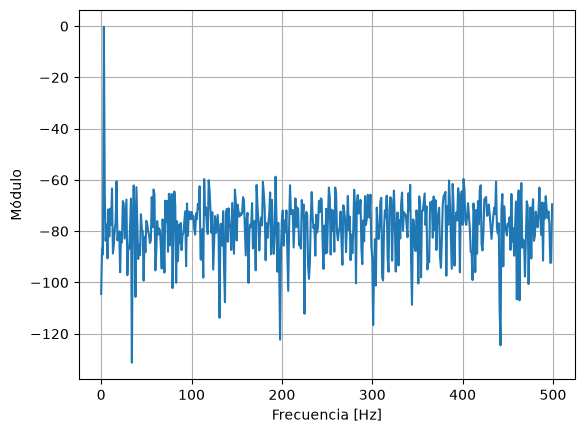

In [7]:

#Invoco la función generadora de senoides
tt, xx = gen_sin( vmax, dc, ff, ph, N, fs) 

#Invoco la función generadora de ruido
ruido = gen_noise (SNR, Psen, ur, N)

#Armo manualmente la señal ruidosa
noisy_xx = xx + ruido

#Armo vector de frecuencia
frec=np.arange(N//2) * fs/N

#Calculo fft de la señal ruidosa
nXX = 1/N*np.fft.fft(noisy_xx)

A = nXX[:N//2]

# Espectro del módulo
plt.plot(frec, 20*np.log10(2*(np.abs(nXX[:N//2])**2))) #normalizo el ruido a 0db
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Módulo")
plt.grid(True)
plt.show()


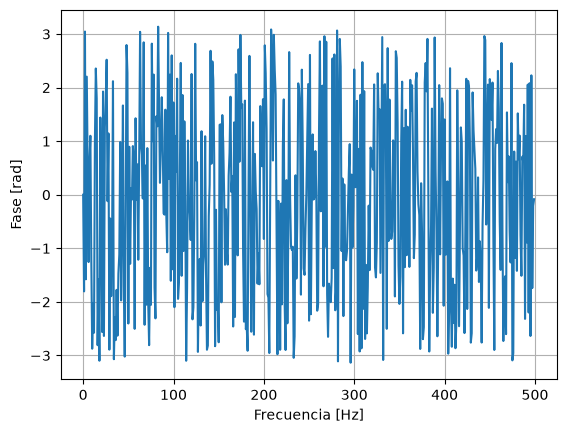

In [8]:
# Espectro de fase
plt.figure()
plt.plot(frec, np.angle(A))
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [rad]")
plt.grid(True)

plt.show()


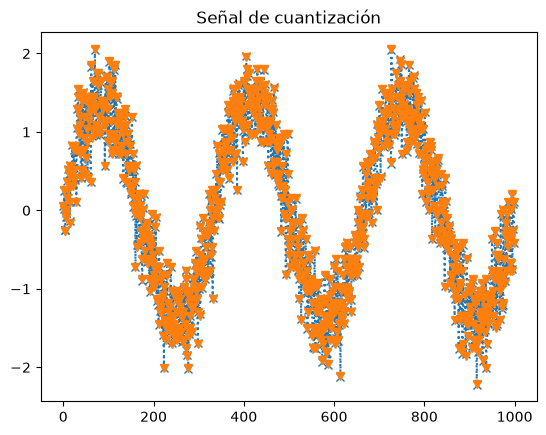

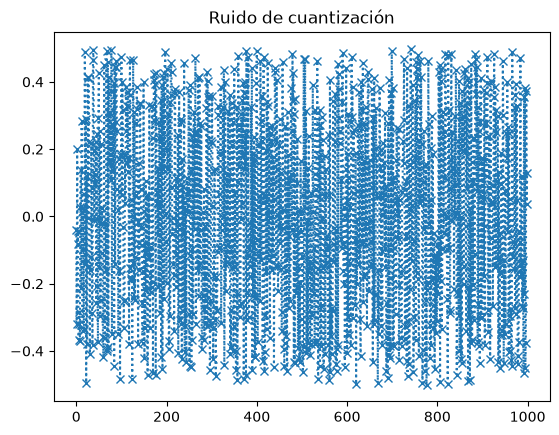

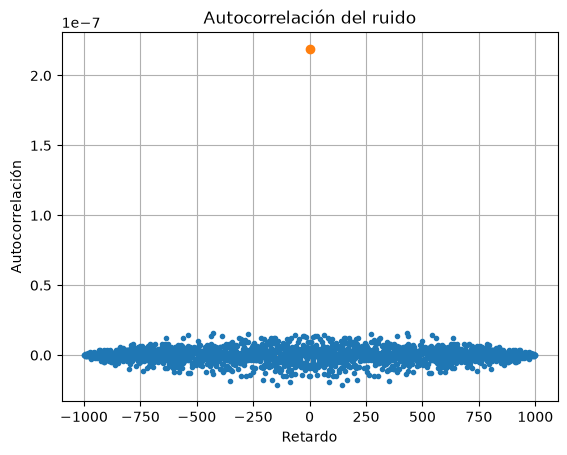

No hay evidencia suficiente para confirmar que la señal no sigue una distribución uniforme.


In [10]:
#ADC
B=6 #bits
Vfs= 1.65 #Volts
qq= 2*Vfs/(2**B)
#%%Cuantizamos
xx_q= np.round(noisy_xx/qq)*qq

ruido_q= xx_q - noisy_xx

plt.figure()

plt.plot(noisy_xx, ':x')
plt.plot(xx_q,'v')
plt.title("Señal de cuantización")

plt.figure()
plt.plot(ruido_q/qq,':x')
plt.title("Ruido de cuantización")

#para verificar que el ruido es uniforme analizo la varianza y la comparo con el valor teorico


#para verificar que el ruido sea incorrelado
ruido_centrado = ruido_q - np.mean(ruido_q)

R = (np.correlate(ruido_centrado, ruido_centrado, mode="full") / len(ruido_q))/N  #esto tiene largo 2N-1 // divido por N para que se pueda comparar con la varianza
#el retardo 0 quedaria en el medio
centro=len(R)//2
retardo_0= R[centro]

varianza = np.var(ruido_q)


retardo_neg = np.arange(-N+1, N)

plt.figure()
plt.plot(retardo_neg, R, '.')


plt.plot(0, R[centro], ":o")

plt.xlabel("Retardo")
plt.ylabel("Autocorrelación")
plt.title("Autocorrelación del ruido")
plt.grid()
plt.show()


a=-qq/2
b=qq/2

resultado= kstest(ruido_q, "uniform", args=(a, b-a))

alpha= 0.5

if resultado.pvalue < alpha: 
    print("La señal no es compatible con una distribución uniforme.")
else: 
    print("No hay evidencia suficiente para confirmar que la señal no sigue una distribución uniforme.")

